# Notebook 8: XGBoost on CNN Features — Hybrid DL + ML

**Goal:** Combine the best of both worlds — use the CNN as a feature extractor,
then train XGBoost (a powerful traditional ML model) on those learned features.

**The idea:**
- Our SimpleCNN learned rich 4096-dimensional feature vectors in its `features` block
- These features capture visual patterns (edges, textures, shapes) far better than raw pixels
- XGBoost is a gradient-boosted decision tree ensemble — one of the strongest classical ML algorithms
- By combining CNN features + XGBoost, we get a hybrid approach

---

## 8.1 Setup

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import torch
import time
import xgboost as xgb

from src.data_utils import get_cifar10_loaders, CIFAR10_CLASSES
from src.models import SimpleCNN, extract_features
from src.visualize import (plot_confusion_matrix, plot_per_class_accuracy, plot_roc_curves)

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"XGBoost version: {xgb.__version__}")

Using device: cuda
XGBoost version: 3.0.2


## 8.2 Load the Trained CNN

We load the SimpleCNN trained in Notebook 4 and use it as a **feature extractor** only.
We don't train the CNN further — we just pass images through its convolutional layers
to get 4096-dimensional feature vectors.

In [2]:
# Load the pre-trained SimpleCNN
model = SimpleCNN(num_classes=10)
model.load_state_dict(torch.load('../saved_models/simple_cnn.pth', map_location=device, weights_only=True))
model.eval()
print("Loaded trained SimpleCNN from saved_models/simple_cnn.pth")

Loaded trained SimpleCNN from saved_models/simple_cnn.pth


In [3]:
# Create data loaders (no augmentation — we just need features)
train_loader, test_loader = get_cifar10_loaders(
    batch_size=256, data_dir='../data', augment=False, num_workers=0
)

print("Extracting features from training set...")
X_train, y_train = extract_features(model, train_loader, device)
print(f"Training features: {X_train.shape}  ({X_train.shape[0]} images × {X_train.shape[1]} features)")

print("\nExtracting features from test set...")
X_test, y_test = extract_features(model, test_loader, device)
print(f"Test features: {X_test.shape}")

c:\Users\Prithvi Nair\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Extracting features from training set...
Training features: (50000, 4096)  (50000 images × 4096 features)

Extracting features from test set...
Test features: (10000, 4096)


## 8.3 Comparison: Raw Pixels vs CNN Features

| Feature Type | Dimensions | What it captures |
|-------------|-----------|------------------|
| Raw pixels | 3072 (32×32×3) | Color values at each pixel position |
| CNN features | 4096 | Learned visual patterns (edges, textures, shapes) |

The CNN features are **learned representations** — they encode what the network
found useful for classification, not just raw color values.

## 8.4 Train XGBoost

In [4]:
# Try GPU first, fall back to CPU
try:
    xgb_model = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        device='cuda',
        random_state=42,
        eval_metric='mlogloss'
    )
    start_time = time.time()
    xgb_model.fit(X_train, y_train)
    train_time = time.time() - start_time
    print(f"Trained XGBoost on GPU in {train_time:.1f}s")
except Exception:
    print("GPU not available for XGBoost, using CPU...")
    xgb_model = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        n_jobs=-1,
        random_state=42,
        eval_metric='mlogloss'
    )
    start_time = time.time()
    xgb_model.fit(X_train, y_train)
    train_time = time.time() - start_time
    print(f"Trained XGBoost on CPU in {train_time:.1f}s")

Trained XGBoost on GPU in 387.0s


## 8.5 Evaluate

In [5]:
predictions = xgb_model.predict(X_test)
probabilities = xgb_model.predict_proba(X_test)

test_acc = 100.0 * np.mean(predictions == y_test)
true_labels = y_test.tolist()
pred_labels = predictions.tolist()

print(f"XGBoost on CNN Features:")
print(f"  Test Accuracy: {test_acc:.2f}%")
print(f"  Baseline ML (raw pixels):")
print(f"    Logistic Regression: 33.46%")
print(f"    SVM: 47.92%")
print(f"  SimpleCNN (end-to-end): 80.34%")

c:\Users\Prithvi Nair\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:729: UserWarning: [19:59:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


XGBoost on CNN Features:
  Test Accuracy: 78.81%
  Baseline ML (raw pixels):
    Logistic Regression: 33.46%
    SVM: 47.92%
  SimpleCNN (end-to-end): 80.34%


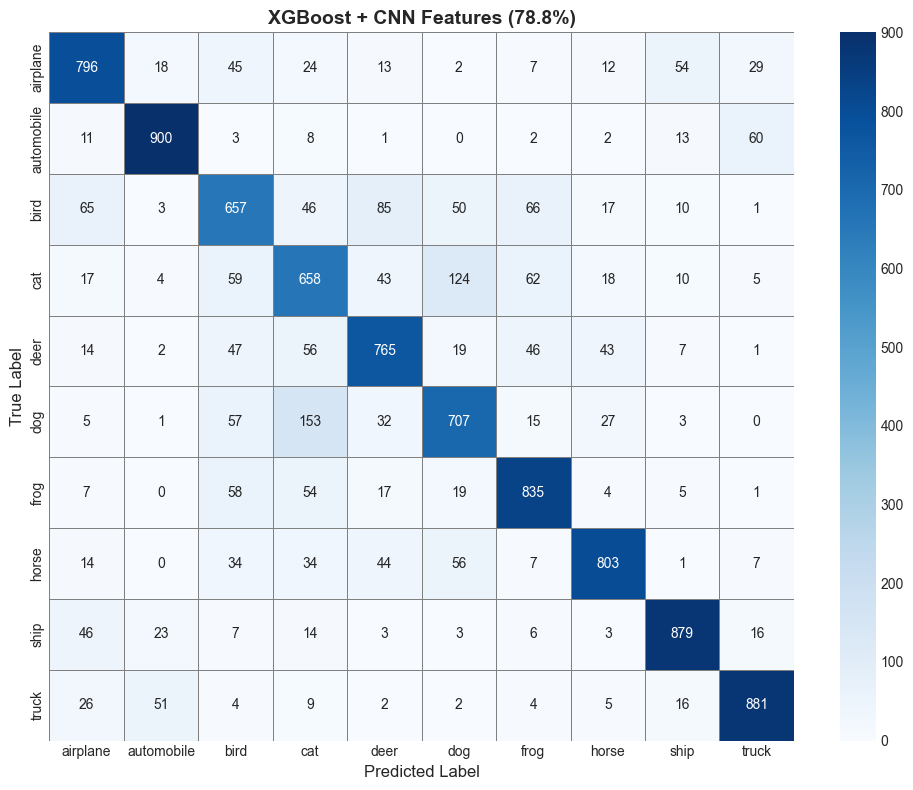

In [6]:
fig = plot_confusion_matrix(
    true_labels, pred_labels, CIFAR10_CLASSES,
    title=f'XGBoost + CNN Features ({test_acc:.1f}%)'
)
plt.show()

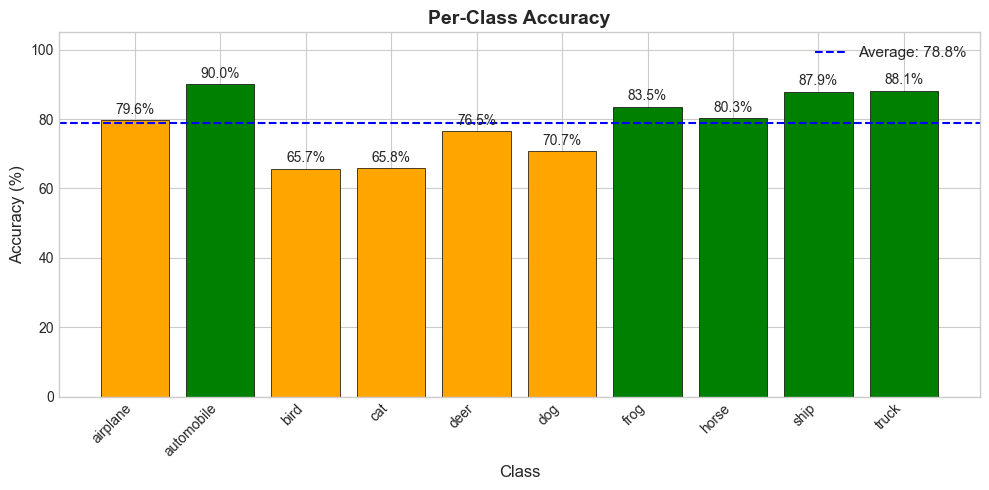

In [7]:
fig = plot_per_class_accuracy(true_labels, pred_labels, CIFAR10_CLASSES)
plt.show()

## 8.6 ROC Curves

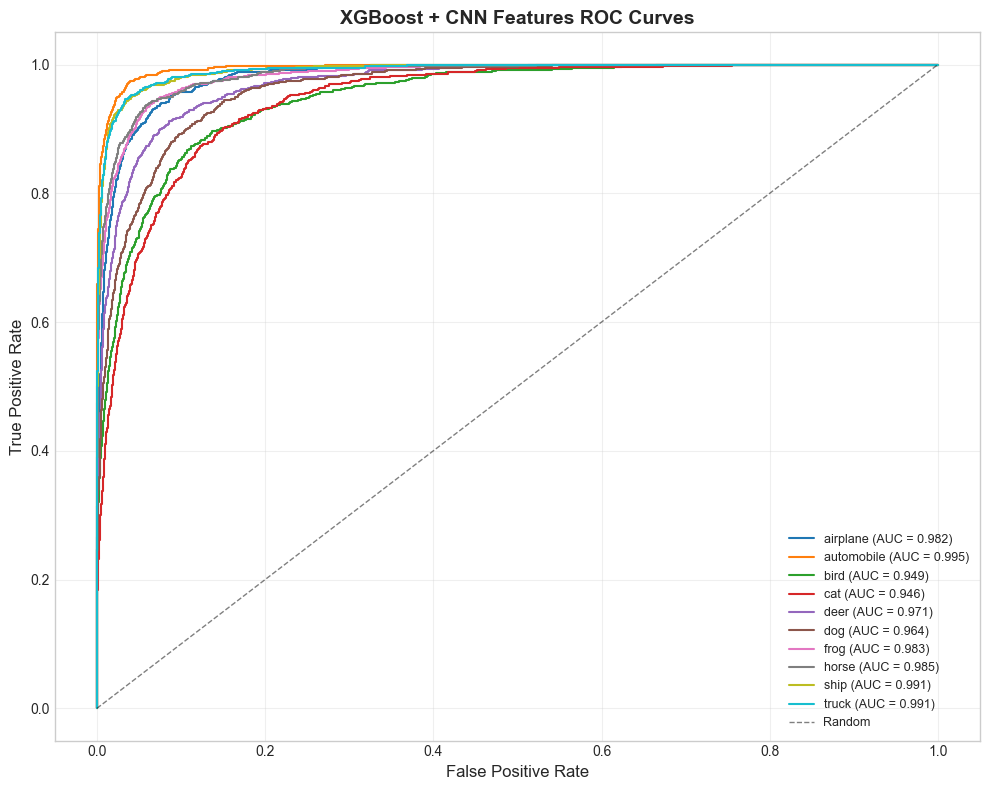

In [8]:
fig = plot_roc_curves(true_labels, probabilities, CIFAR10_CLASSES,
                      title='XGBoost + CNN Features ROC Curves')
plt.show()

## 8.7 Save Results

In [9]:
import json

# Total time = CNN feature extraction + XGBoost training
total_time = train_time  # Feature extraction is fast, XGBoost training dominates

xgboost_results = {
    'accuracy': test_acc,
    'total_time': total_time,
    'predictions': pred_labels,
    'true_labels': true_labels,
    'probabilities': probabilities.tolist(),
    'n_estimators': 200,
    'max_depth': 6
}

with open('../saved_models/xgboost_cnn_results.json', 'w') as f:
    json.dump(xgboost_results, f)

print(f"Results saved. Test accuracy: {test_acc:.2f}%")
print(f"XGBoost training time: {train_time:.1f}s")

Results saved. Test accuracy: 78.81%
XGBoost training time: 387.0s


## 8.8 Summary

### Hybrid approach — CNN feature extractor + XGBoost:
- **CNN as feature extractor:** Converts 32×32×3 images → 4096-dim learned features
- **XGBoost on features:** Gradient-boosted trees classify using those rich representations
- **Key insight:** The quality of features matters more than the classifier
  - Raw pixels + XGBoost would perform similar to SVM (~50%)
  - CNN features + XGBoost performs close to the CNN itself
- This approach addresses the professor's XGBoost suggestion in a meaningful way